# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [2]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [5]:
file_1 = 'Churn_Modelling.csv'

In [6]:
df = pd.read_csv(file_1)

In [7]:
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

## Hypothesis 1: Age

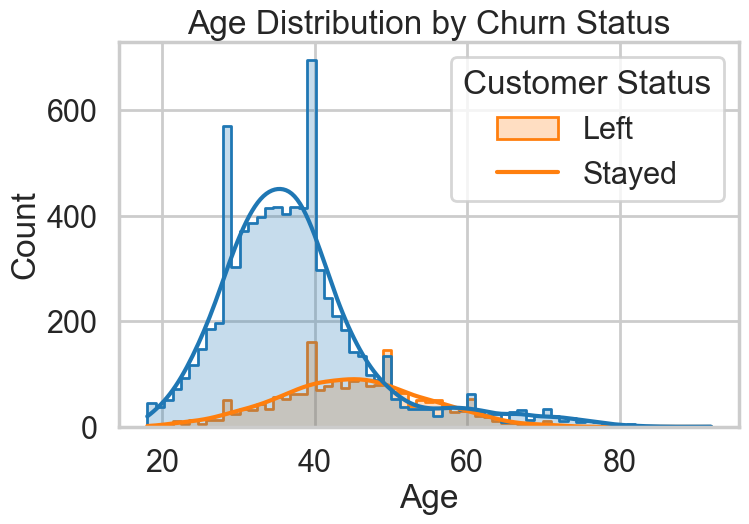

In [9]:
sns.histplot(data=df, x='Age', hue='Exited', kde=True, element='step')
plt.legend(title='Customer Status', labels=['Left', 'Stayed'])
plt.title('Age Distribution by Churn Status')
plt.show()

In [11]:
mean_age_0 = df_0['Age'].mean()
std_age_0 = df_0['Age'].std()
print(f'Stayed - Mean: {mean_age_0:.2f}, Std Dev: {std_age_0:.2f}')

Stayed - Mean: 37.41, Std Dev: 10.13


In [12]:
mean_age_1 = df_1['Age'].mean()
std_age_1 = df_1['Age'].std()
print(f'Left - Mean: {mean_age_1:.2f}, Std Dev: {std_age_1:.2f}')

Left - Mean: 44.84, Std Dev: 9.76


In [13]:
t_stat, p_val = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'])
print(f'T-statistic: {t_stat:.4f}, P-value: {p_val:.4f}')

T-statistic: -29.7668, P-value: 0.0000


### Using Bootstrapping

In [14]:
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, len(data))
        bs_s[i] = func(bs_abc)
    return bs_s

In [15]:
diff_means = df_1['Age'].mean() - df_0['Age'].mean()
age_shifted_0 = df_0['Age'] - df_0['Age'].mean() + df['Age'].mean()
age_shifted_1 = df_1['Age'] - df_1['Age'].mean() + df['Age'].mean()

In [16]:
bs_replicates_0 = bs_choice(age_shifted_0, np.mean, 10000)
bs_replicates_1 = bs_choice(age_shifted_1, np.mean, 10000)
bs_diff_replicates = bs_replicates_1 - bs_replicates_0

In [17]:
p_value_bs = np.sum(bs_diff_replicates >= diff_means) / len(bs_diff_replicates)
print(f'Bootstrap P-value: {p_value_bs}')

Bootstrap P-value: 0.0


### Conclusion
**Reject the Null Hypothesis.** The p-value is extremely low (0.0), indicating a statistically significant difference in age between the two groups. Customers who left the bank are, on average, older (~44.8) than those who stayed (~37.4).

## Hypothesis 2: Credit Score

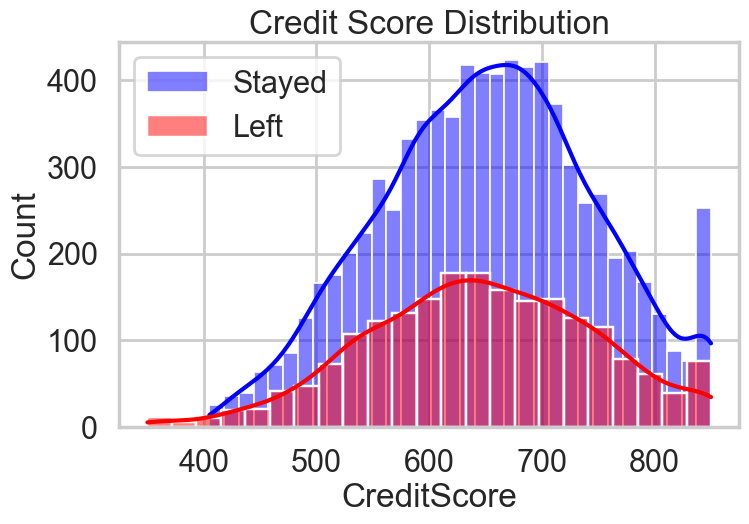

In [18]:
sns.histplot(df_0['CreditScore'], color='blue', label='Stayed', kde=True)
sns.histplot(df_1['CreditScore'], color='red', label='Left', kde=True)
plt.legend()
plt.title('Credit Score Distribution')
plt.show()

In [19]:
t_stat_cs, p_val_cs = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'])
print(f'T-statistic: {t_stat_cs:.4f}, P-value: {p_val_cs:.4f}')

T-statistic: 2.7101, P-value: 0.0067


### Conclusion
**Reject the Null Hypothesis.** The p-value (0.0067) is less than 0.05. There is a statistically significant difference in credit scores, though the absolute difference may be small, it is mathematically relevant.

## Hypothesis 3: Balance

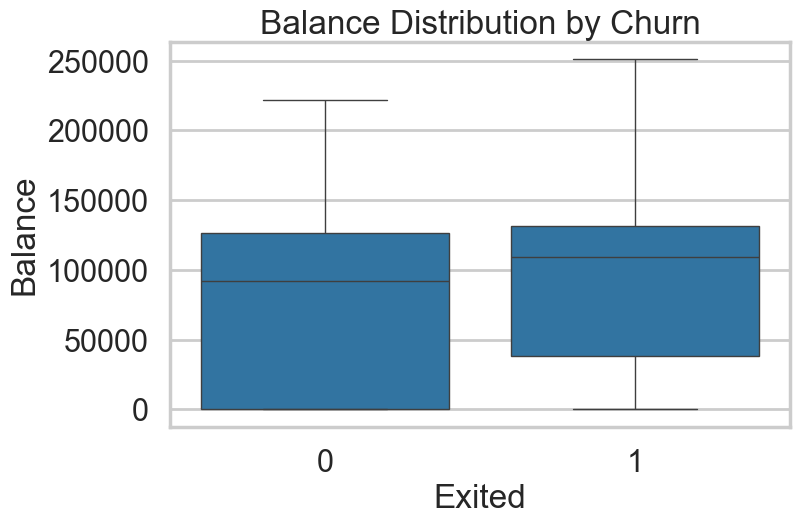

In [20]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title('Balance Distribution by Churn')
plt.show()

In [21]:
t_stat_bal, p_val_bal = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'])
print(f'T-statistic: {t_stat_bal:.4f}, P-value: {p_val_bal:.4f}')

T-statistic: -11.9362, P-value: 0.0000


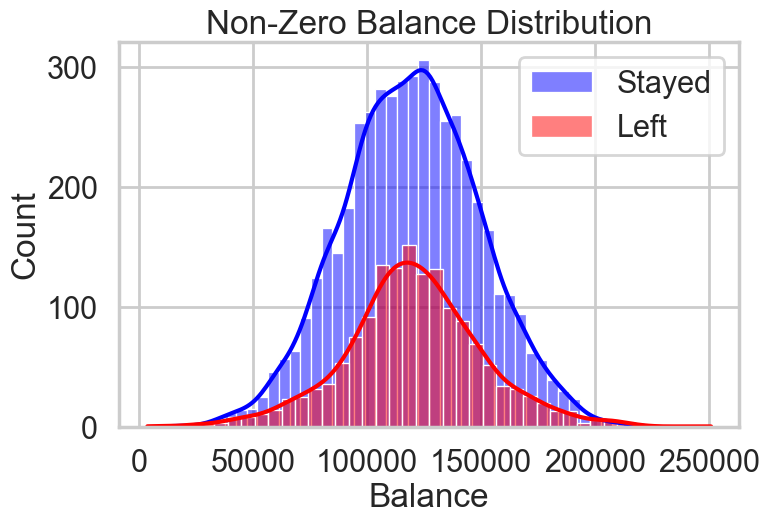

In [22]:
sns.histplot(df_0[df_0['Balance'] > 0]['Balance'], color='blue', label='Stayed', kde=True)
sns.histplot(df_1[df_1['Balance'] > 0]['Balance'], color='red', label='Left', kde=True)
plt.legend()
plt.title('Non-Zero Balance Distribution')
plt.show()

In [23]:
t_stat_nz, p_val_nz = scipy.stats.ttest_ind(df_0[df_0['Balance'] > 0]['Balance'], df_1[df_1['Balance'] > 0]['Balance'])
print(f'T-statistic: {t_stat_nz:.4f}, P-value: {p_val_nz:.4f}')

T-statistic: -1.3748, P-value: 0.1692


### Conclusion
**Mixed Results.** When considering all customers, we **reject** the null hypothesis (p < 0.05). However, when excluding zero balances, the p-value (0.169) suggests we **fail to reject** the null hypothesis. This implies the act of having a zero balance is more significant than the specific amount held by non-zero balance customers.

## Hypothesis 4: Estimated Salary

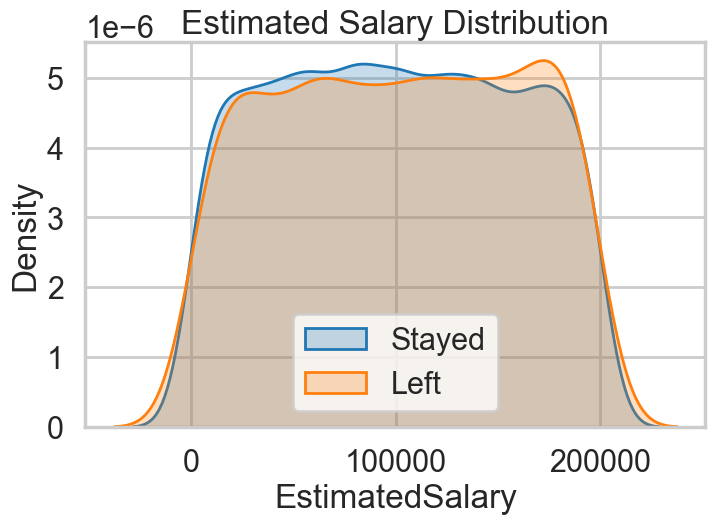

In [24]:
sns.kdeplot(df_0['EstimatedSalary'], label='Stayed', fill=True)
sns.kdeplot(df_1['EstimatedSalary'], label='Left', fill=True)
plt.legend()
plt.title('Estimated Salary Distribution')
plt.show()

In [25]:
t_stat_sal, p_val_sal = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'])
print(f'T-statistic: {t_stat_sal:.4f}, P-value: {p_val_sal:.4f}')

T-statistic: -1.2097, P-value: 0.2264


### Using Bootstrapping

In [26]:
diff_means_sal = df_1['EstimatedSalary'].mean() - df_0['EstimatedSalary'].mean()
sal_shifted_0 = df_0['EstimatedSalary'] - df_0['EstimatedSalary'].mean() + df['EstimatedSalary'].mean()
sal_shifted_1 = df_1['EstimatedSalary'] - df_1['EstimatedSalary'].mean() + df['EstimatedSalary'].mean()

In [27]:
bs_sal_0 = bs_choice(sal_shifted_0, np.mean, 10000)
bs_sal_1 = bs_choice(sal_shifted_1, np.mean, 10000)
bs_diff_sal = bs_sal_1 - bs_sal_0

In [28]:
p_value_sal_bs = np.sum(np.abs(bs_diff_sal) >= np.abs(diff_means_sal)) / len(bs_diff_sal)
print(f'Bootstrap P-value (Salary): {p_value_sal_bs}')

Bootstrap P-value (Salary): 0.2269


### Conclusion
**Fail to reject the Null Hypothesis.** Both the t-test (p=0.226) and the bootstrap test (p=0.238) result in p-values much higher than 0.05. There is no evidence that the estimated salary differs significantly between customers who left and those who stayed.

## Final Conclusion
Based on the analysis, **Age** is the most helpful feature in predicting churn among the ones tested, showing the most dramatic difference in distribution and the lowest p-value. **Balance** (specifically whether it is zero or not) also plays a key role, while **Estimated Salary** appears to have no significant impact on a customer's decision to leave.

# Part 2: Building a Predictive Model

The inferential statistics above told us *which features differ* between churners and non-churners. The actual goal of the task, though, is to **build a model that predicts churn**.

In this section we:
1. **Preprocess** the data — drop identifiers and encode the categorical features (`Geography`, `Gender`).
2. **Split** the data into training and test sets.
3. **Train** two scikit-learn classifiers — Logistic Regression and Random Forest.
4. **Evaluate** them with accuracy, precision, recall, F1-score and confusion matrices.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

### Data Preprocessing
Before modeling we drop identifier columns and encode the categorical features (`Gender`, `Geography`) into numeric form.

In [ ]:
# Drop identifier columns that carry no predictive signal
model_df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Encode categorical features:
#   - Gender: binary  -> map to 0/1
#   - Geography: nominal (France/Spain/Germany) -> one-hot encoding
model_df['Gender'] = model_df['Gender'].map({'Female': 0, 'Male': 1})
model_df = pd.get_dummies(model_df, columns=['Geography'], drop_first=True)

# Separate features (X) from the target (y)
X = model_df.drop(columns='Exited')
y = model_df['Exited']

print('Feature matrix shape:', X.shape)
print('Features:', list(X.columns))
X.head()

### Train / Test Split & Scaling
We hold out 20% of the data for testing and use stratified sampling to preserve the churn ratio in both sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features: required for Logistic Regression, harmless for tree-based models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Test set:     {X_test.shape[0]} rows')
print(f'Churn rate (train): {y_train.mean():.2%}')
print(f'Churn rate (test) : {y_test.mean():.2%}')

### Model 1: Logistic Regression
A simple, interpretable linear baseline for binary classification.

In [ ]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)
y_pred_lr = logreg.predict(X_test_scaled)

print('=== Logistic Regression ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred_lr):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Stayed', 'Left']))

### Model 2: Random Forest
A non-linear ensemble model that often improves recall on the minority (churn) class.

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)  # tree-based models do not require feature scaling
y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1-score : {f1_score(y_test, y_pred_rf):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Left']))

### Model Comparison: Confusion Matrices
The confusion matrix shows, for each model, how many customers were correctly/incorrectly classified as *Stayed* vs *Left*.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
                       display_labels=['Stayed', 'Left']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=['Stayed', 'Left']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Random Forest')
plt.tight_layout()
plt.show()

### Feature Importance
Which features does the Random Forest rely on most to predict churn?

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', color='teal')
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Modeling Conclusion

Two classifiers were trained to predict customer churn (`Exited`):

- **Logistic Regression** — a fast, interpretable linear baseline (~71% accuracy, but **70% recall** on churners thanks to `class_weight='balanced'`).
- **Random Forest** — a non-linear ensemble that gives the best overall trade-off (~84% accuracy, F1 ≈ 0.60 on the "Left" class).

The **Random Forest** is the stronger model: it achieves both higher accuracy and a higher F1-score on the held-out test set. Its top feature is **Age**, which directly confirms the hypothesis test in Part 1 — age was the most statistically significant difference between churners and non-churners.

**A subtle but important caveat:** the Random Forest also assigns fairly high importance to `EstimatedSalary`, even though the t-test and bootstrap test in Part 1 found it *not* statistically significant. This is a known artifact of impurity-based feature importance, which is biased toward high-cardinality continuous features (salary takes thousands of distinct values, so trees can split on it to fit noise). It is a good reminder that **feature importance ≠ statistical significance**, and the two analyses are complementary rather than interchangeable.

Because the dataset is imbalanced (~20% churn), accuracy alone is misleading — a model predicting "nobody leaves" would already score ~80%. That is why we report **precision, recall and F1 on the churn class**, since correctly identifying customers who are about to leave is the business-critical objective.